# LLM-as-Judge: GPT-4.1 Evaluation of RAG Generation Quality

**Evaluates the outputs from Mrigi 23e (GreenandNew_90 Question Bank)**

This notebook uses GPT-4.1 as a judge to evaluate the quality of Llama-3-8B-Instruct responses
across all retrieval methods and k values from notebook 23e.

**Three Evaluation Tasks (scored 1-10 with reasoning):**
1. **Context Relevance** — Given a query, how relevant is the retrieved context?
2. **Response Correctness** — Given the context, how correct is the model's response?
3. **Response Completeness** — Given the query, how complete is the model's response?

**Input:**
- Complete results JSON from 23e (`results_23e_complete_*.json`) containing `detailed_results`
  with `query`, `context`, `model_answer`, `correct_answer`, `full_response`, `explanation`

**Configuration:**
- 3 categories: Synthesis (30), ChemCon (30), DAC (30) = 90 questions
- 7 methods: abstract, no_context, faiss, mmr, bm25, hybrid, optimized
- k values: 10, 15 (baselines abstract/no_context are k-independent)
- Judge: GPT-4.1 via OpenAI API

**Output:**
- Per-question JSON scores with reasoning
- Aggregated visualizations per method, k, and category

In [23]:
!nvidia-smi

Tue Mar  3 21:55:43 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.119.02             Driver Version: 580.119.02     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX A5000               Off |   00000000:31:00.0 Off |                  Off |
| 30%   28C    P8             11W /  230W |     983MiB /  24564MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [24]:
# Core imports
import os
import json
import glob
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from tqdm import tqdm
from openai import OpenAI
import httpx

# Load environment variables (OPENAI_API_TOKEN, HF_TOKEN)
# Note: !source runs in a subprocess and doesn't persist env vars into Python.
# Parse env.sh directly instead.
with open('/home/jupyter/Mrigi/env.sh') as f:
    for line in f:
        line = line.strip()
        if line.startswith('export ') and '=' in line:
            key, val = line[len('export '):].split('=', 1)
            os.environ[key] = val.strip('"').strip("'")

openai_key = os.environ.get("OPENAI_API_TOKEN")

if not openai_key:
    raise ValueError(
        "OPENAI_API_TOKEN not found in environment. "
        "Add it to /home/jupyter/Mrigi/env.sh and re-run this cell."
    )

client = OpenAI(api_key=openai_key, http_client=httpx.Client())
print(f"\u2713 OpenAI client initialized")
print(f"\u2713 Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✓ OpenAI client initialized
✓ Timestamp: 2026-03-03 21:55:44


## Load Complete Results from 23e

Load the JSON file that contains `detailed_results` for every method/k/category combination.
The file is expected to be named `results_23e_complete_*.json` in the working directory.

In [25]:
# Find the most recent complete results file from 23e
# Look for files matching the naming pattern from 23e's save cell
patterns = [
    'results_23e_complete_*.json',
]

results_file = None
for pattern in patterns:
    matches = sorted(glob.glob(pattern))
    if matches:
        results_file = matches[-1]  # most recent
        break

if results_file is None:
    # List all JSON results files for manual selection
    all_json = sorted(glob.glob('results_*.json'))
    print("Available results files:")
    for f in all_json:
        size_mb = os.path.getsize(f) / (1024 * 1024)
        print(f"  {f}  ({size_mb:.1f} MB)")
    raise FileNotFoundError(
        "No complete results file found. "
        "Run the last cell of 23e to save results_23e_complete_*.json first."
    )

print(f"Loading results from: {results_file}")
print(f"File size: {os.path.getsize(results_file) / (1024*1024):.1f} MB")

with open(results_file, 'r') as f:
    all_results = json.load(f)

# Inspect structure
for model_name in all_results:
    print(f"\nModel: {model_name}")
    for k_label in all_results[model_name]:
        print(f"  {k_label}:")
        for cat in all_results[model_name][k_label]:
            methods = list(all_results[model_name][k_label][cat].keys())
            # Check if detailed_results exists
            sample = all_results[model_name][k_label][cat].get(methods[0], {})
            has_detailed = 'detailed_results' in sample
            print(f"    {cat}: {methods} (detailed_results: {has_detailed})")

Loading results from: results_23e_complete_20260303_215326.json
File size: 18.7 MB

Model: Llama-3-8B-Instruct
  k=10:
    Synthesis: ['abstract', 'no_context', 'faiss', 'mmr', 'bm25', 'hybrid', 'optimized'] (detailed_results: True)
    ChemCon: ['abstract', 'no_context', 'faiss', 'mmr', 'bm25', 'hybrid', 'optimized'] (detailed_results: True)
    DAC: ['abstract', 'no_context', 'faiss', 'mmr', 'bm25', 'hybrid', 'optimized'] (detailed_results: True)
  k=15:
    Synthesis: ['faiss', 'mmr', 'bm25', 'hybrid', 'optimized'] (detailed_results: True)
    ChemCon: ['faiss', 'mmr', 'bm25', 'hybrid', 'optimized'] (detailed_results: True)
    DAC: ['faiss', 'mmr', 'bm25', 'hybrid', 'optimized'] (detailed_results: True)


In [26]:
# Configuration: extract structure from loaded results
MODEL_NAME = list(all_results.keys())[0]  # e.g., 'Llama-3-8B-Instruct'
K_LABELS = sorted(all_results[MODEL_NAME].keys())  # e.g., ['k=10', 'k=15']
ALL_CATEGORIES = list(all_results[MODEL_NAME][K_LABELS[0]].keys())  # e.g., ['Synthesis', 'ChemCon', 'DAC']
ALL_METHODS = list(all_results[MODEL_NAME][K_LABELS[0]][ALL_CATEGORIES[0]].keys())

# Baselines are k-independent: abstract and no_context
BASELINE_METHODS = ['abstract', 'no_context']
RETRIEVAL_METHODS = [m for m in ALL_METHODS if m not in BASELINE_METHODS]

print(f"Model: {MODEL_NAME}")
print(f"K labels: {K_LABELS}")
print(f"Categories: {ALL_CATEGORIES}")
print(f"All methods: {ALL_METHODS}")
print(f"Baseline methods: {BASELINE_METHODS}")
print(f"Retrieval methods: {RETRIEVAL_METHODS}")

# Verify detailed_results are present
sample = all_results[MODEL_NAME][K_LABELS[0]][ALL_CATEGORIES[0]][ALL_METHODS[0]]
if 'detailed_results' not in sample:
    print("\n⚠ WARNING: detailed_results NOT found in loaded file!")
    print("  This notebook requires the complete results file with detailed_results.")
    print("  The intermediate saves from 23e strip detailed_results.")
    print("  You need to either:")
    print("    1. Re-run 23e and save complete results with detailed_results, OR")
    print("    2. Point results_file to a file that includes detailed_results.")
else:
    n_sample = len(sample['detailed_results'])
    keys_sample = list(sample['detailed_results'][0].keys()) if n_sample > 0 else []
    print(f"\n\u2713 detailed_results present: {n_sample} entries")
    print(f"  Keys per entry: {keys_sample}")

Model: Llama-3-8B-Instruct
K labels: ['k=10', 'k=15']
Categories: ['Synthesis', 'ChemCon', 'DAC']
All methods: ['abstract', 'no_context', 'faiss', 'mmr', 'bm25', 'hybrid', 'optimized']
Baseline methods: ['abstract', 'no_context']
Retrieval methods: ['faiss', 'mmr', 'bm25', 'hybrid', 'optimized']

✓ detailed_results present: 30 entries
  Keys per entry: ['query', 'context', 'model_answer', 'correct_answer', 'is_correct', 'full_response', 'explanation']


## Define GPT-4.1 Judge Prompts

Three evaluation tasks, each scored 1-10 with reasoning:
1. **Context Relevance** — Is the retrieved context relevant to answering the query?
2. **Response Correctness** — Is the model's answer factually correct given the context?
3. **Response Completeness** — Does the response fully address the query?

In [27]:
# ============================================================
# GPT-4.1 Judge Prompts
# ============================================================

JUDGE_SYSTEM_PROMPT = """You are an expert evaluator for a Retrieval-Augmented Generation (RAG) system 
focused on zeolite synthesis, catalysis, and environmental applications. 
You will evaluate the quality of retrieved contexts and generated responses.
Always respond in valid JSON format."""

# Task 1: Context Relevance
CONTEXT_RELEVANCE_PROMPT = """Given the following query and retrieved context, rate how relevant the context is for answering the query.

**Scoring Rubric (1-10):**
- 1-2: Completely irrelevant — context has no connection to the query topic
- 3-4: Mostly irrelevant — context touches on the general domain but doesn't address the specific question
- 5-6: Partially relevant — context contains some useful information but misses key aspects
- 7-8: Mostly relevant — context addresses the main topic and provides useful information for answering
- 9-10: Highly relevant — context directly addresses the query with specific, useful information

**Query:**
{query}

**Retrieved Context:**
{context}

Respond with ONLY a JSON object in this exact format:
{{"score": <integer 1-10>, "reasoning": "<one to two sentences explaining your score>"}}"""

# Task 2: Response Correctness
RESPONSE_CORRECTNESS_PROMPT = """Given the following query, context, model response, and the correct answer, rate how correct the model's response is.

**Scoring Rubric (1-10):**
- 1-2: Completely incorrect — wrong answer with wrong reasoning
- 3-4: Mostly incorrect — wrong answer, but reasoning shows partial understanding
- 5-6: Partially correct — right answer but weak/incorrect reasoning, OR wrong answer with sound reasoning
- 7-8: Mostly correct — right answer with reasonable explanation
- 9-10: Fully correct — right answer with accurate, well-supported explanation

**Query:**
{query}

**Context Provided to Model:**
{context}

**Model's Full Response:**
{response}

**Correct Answer:** {correct_answer}
**Model's Answer:** {model_answer}

Respond with ONLY a JSON object in this exact format:
{{"score": <integer 1-10>, "reasoning": "<one to two sentences explaining your score>"}}"""

# Task 3: Response Completeness
RESPONSE_COMPLETENESS_PROMPT = """Given the following query and model response, rate how complete the response is in addressing the question.

**Scoring Rubric (1-10):**
- 1-2: No meaningful response — empty, garbled, or completely off-topic
- 3-4: Minimal response — provides an answer letter but no useful explanation
- 5-6: Partial response — provides answer with brief explanation but lacks depth
- 7-8: Good response — provides answer with clear, relevant explanation
- 9-10: Excellent response — provides answer with thorough, well-reasoned explanation that demonstrates understanding

**Query:**
{query}

**Model's Full Response:**
{response}

Respond with ONLY a JSON object in this exact format:
{{"score": <integer 1-10>, "reasoning": "<one to two sentences explaining your score>"}}"""

print("✓ Judge prompts defined (3 tasks: relevance, correctness, completeness)")

✓ Judge prompts defined (3 tasks: relevance, correctness, completeness)


In [28]:
# ============================================================
# GPT-4.1 Judge Function
# ============================================================

def call_gpt41_judge(system_prompt, user_prompt, max_retries=3, retry_delay=5):
    """
    Call GPT-4.1 as judge and parse the JSON response.
    
    Args:
        system_prompt: System message for GPT-4.1
        user_prompt: User message with the evaluation task
        max_retries: Number of retries on failure
        retry_delay: Seconds to wait between retries
    
    Returns:
        dict: {'score': int, 'reasoning': str} or {'score': -1, 'reasoning': 'error message'}
    """
    for attempt in range(max_retries):
        try:
            response = client.chat.completions.create(
                model="gpt-4.1",
                messages=[
                    {"role": "system", "content": system_prompt},
                    {"role": "user", "content": user_prompt}
                ],
                temperature=0.1,
                max_tokens=200,
                response_format={"type": "json_object"}
            )
            
            content = response.choices[0].message.content.strip()
            result = json.loads(content)
            
            # Validate score
            score = int(result.get('score', -1))
            if 1 <= score <= 10:
                return {
                    'score': score,
                    'reasoning': result.get('reasoning', '')
                }
            else:
                # Score out of range, retry
                if attempt < max_retries - 1:
                    time.sleep(retry_delay)
                    continue
                return {'score': score, 'reasoning': f"Score out of range: {result}"}
                
        except json.JSONDecodeError as e:
            if attempt < max_retries - 1:
                time.sleep(retry_delay)
                continue
            return {'score': -1, 'reasoning': f"JSON parse error: {str(e)}"}
            
        except Exception as e:
            if attempt < max_retries - 1:
                time.sleep(retry_delay)
                continue
            return {'score': -1, 'reasoning': f"API error: {str(e)}"}
    
    return {'score': -1, 'reasoning': 'Max retries exceeded'}


def evaluate_single_question(question_result, method_name):
    """
    Run all 3 judge tasks on a single question result from 23e.
    
    Args:
        question_result: dict with query, context, model_answer, correct_answer, full_response, etc.
        method_name: Name of the retrieval method (for special handling of no_context)
    
    Returns:
        dict with relevance, correctness, completeness scores and reasoning
    """
    query = question_result.get('query', '')
    context = question_result.get('context', '')
    model_answer = question_result.get('model_answer', '')
    correct_answer = question_result.get('correct_answer', '')
    full_response = question_result.get('full_response', '')
    explanation = question_result.get('explanation', '')
    
    # Build the full model response string
    response_text = full_response if full_response else f"Answer: {model_answer} - {explanation}"
    
    # --- Task 1: Context Relevance ---
    # Skip for no_context method (no context was provided)
    if method_name == 'no_context' or not context:
        relevance = {'score': -1, 'reasoning': 'N/A — no context provided for this method'}
    else:
        # Truncate context to ~3000 chars to avoid token limits
        ctx_truncated = context[:3000] + '...' if len(context) > 3000 else context
        relevance_prompt = CONTEXT_RELEVANCE_PROMPT.format(
            query=query, context=ctx_truncated
        )
        relevance = call_gpt41_judge(JUDGE_SYSTEM_PROMPT, relevance_prompt)
    
    # --- Task 2: Response Correctness ---
    ctx_for_correctness = context[:2000] + '...' if len(context) > 2000 else context if context else 'No context provided'
    correctness_prompt = RESPONSE_CORRECTNESS_PROMPT.format(
        query=query,
        context=ctx_for_correctness,
        response=response_text,
        correct_answer=correct_answer,
        model_answer=model_answer
    )
    correctness = call_gpt41_judge(JUDGE_SYSTEM_PROMPT, correctness_prompt)
    
    # --- Task 3: Response Completeness ---
    completeness_prompt = RESPONSE_COMPLETENESS_PROMPT.format(
        query=query,
        response=response_text
    )
    completeness = call_gpt41_judge(JUDGE_SYSTEM_PROMPT, completeness_prompt)
    
    return {
        'query': query,
        'model_answer': model_answer,
        'correct_answer': correct_answer,
        'is_correct': question_result.get('is_correct', False),
        'relevance_score': relevance['score'],
        'relevance_reasoning': relevance['reasoning'],
        'correctness_score': correctness['score'],
        'correctness_reasoning': correctness['reasoning'],
        'completeness_score': completeness['score'],
        'completeness_reasoning': completeness['reasoning']
    }

print("✓ Judge functions defined (call_gpt41_judge + evaluate_single_question)")

✓ Judge functions defined (call_gpt41_judge + evaluate_single_question)


## Run LLM-as-Judge Evaluation

Iterate over all methods, k values, and categories. For each question, call GPT-4.1
to score context relevance, response correctness, and response completeness.

Results are saved incrementally after each method to prevent data loss.

In [29]:
# ============================================================
# Build the evaluation plan
# ============================================================
# For baselines (abstract, no_context), only evaluate under k=10 (they are k-independent)
# For retrieval methods, evaluate under all k labels

eval_plan = []
for k_label in K_LABELS:
    for cat in ALL_CATEGORIES:
        for method in ALL_METHODS:
            # Skip baselines at k=15 (they're identical to k=10)
            if method in BASELINE_METHODS and k_label != K_LABELS[0]:
                continue
            
            result_data = all_results.get(MODEL_NAME, {}).get(k_label, {}).get(cat, {}).get(method, {})
            detailed = result_data.get('detailed_results', [])
            
            if detailed:
                eval_plan.append({
                    'k_label': k_label,
                    'category': cat,
                    'method': method,
                    'n_questions': len(detailed)
                })

total_questions = sum(ep['n_questions'] for ep in eval_plan)
total_api_calls = total_questions * 3  # 3 tasks per question (some relevance calls skipped for no_context)

print(f"Evaluation Plan:")
print(f"  Total method/k/category combinations: {len(eval_plan)}")
print(f"  Total questions to judge: {total_questions}")
print(f"  Estimated API calls: ~{total_api_calls} (minus skipped relevance for no_context)")
print(f"\nBreakdown:")
for ep in eval_plan:
    print(f"  {ep['k_label']} | {ep['category']:<12} | {ep['method']:<12} | {ep['n_questions']} questions")

Evaluation Plan:
  Total method/k/category combinations: 36
  Total questions to judge: 1080
  Estimated API calls: ~3240 (minus skipped relevance for no_context)

Breakdown:
  k=10 | Synthesis    | abstract     | 30 questions
  k=10 | Synthesis    | no_context   | 30 questions
  k=10 | Synthesis    | faiss        | 30 questions
  k=10 | Synthesis    | mmr          | 30 questions
  k=10 | Synthesis    | bm25         | 30 questions
  k=10 | Synthesis    | hybrid       | 30 questions
  k=10 | Synthesis    | optimized    | 30 questions
  k=10 | ChemCon      | abstract     | 30 questions
  k=10 | ChemCon      | no_context   | 30 questions
  k=10 | ChemCon      | faiss        | 30 questions
  k=10 | ChemCon      | mmr          | 30 questions
  k=10 | ChemCon      | bm25         | 30 questions
  k=10 | ChemCon      | hybrid       | 30 questions
  k=10 | ChemCon      | optimized    | 30 questions
  k=10 | DAC          | abstract     | 30 questions
  k=10 | DAC          | no_context   | 30 que

In [30]:
# ============================================================
# Run the evaluation
# ============================================================
judge_results = {}  # judge_results[k_label][category][method] = [list of per-question judge dicts]
judge_timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

total_evaluated = 0
start_time = time.time()

for ep in eval_plan:
    k_label = ep['k_label']
    cat = ep['category']
    method = ep['method']
    
    # Initialize nested dicts
    if k_label not in judge_results:
        judge_results[k_label] = {}
    if cat not in judge_results[k_label]:
        judge_results[k_label][cat] = {}
    
    detailed = all_results[MODEL_NAME][k_label][cat][method]['detailed_results']
    
    print(f"\n{'='*80}")
    print(f"Judging: {k_label} | {cat} | {method.upper()} ({len(detailed)} questions)")
    print(f"{'='*80}")
    
    method_judge_results = []
    
    for i, q_result in enumerate(tqdm(detailed, desc=f"{method} ({cat})")):
        # Skip ERROR/INVALID entries — still record them but with -1 scores
        if q_result.get('model_answer') in ['ERROR', 'INVALID']:
            method_judge_results.append({
                'query': q_result.get('query', ''),
                'model_answer': q_result.get('model_answer', ''),
                'correct_answer': q_result.get('correct_answer', ''),
                'is_correct': False,
                'relevance_score': -1,
                'relevance_reasoning': 'Skipped — model returned ERROR/INVALID',
                'correctness_score': -1,
                'correctness_reasoning': 'Skipped — model returned ERROR/INVALID',
                'completeness_score': -1,
                'completeness_reasoning': 'Skipped — model returned ERROR/INVALID'
            })
            total_evaluated += 1
            continue
        
        judge_eval = evaluate_single_question(q_result, method)
        method_judge_results.append(judge_eval)
        total_evaluated += 1
        
        # Rate limiting: small delay to avoid hitting API limits
        time.sleep(0.2)
    
    judge_results[k_label][cat][method] = method_judge_results
    
    # Print summary for this method
    valid_rel = [r['relevance_score'] for r in method_judge_results if r['relevance_score'] > 0]
    valid_cor = [r['correctness_score'] for r in method_judge_results if r['correctness_score'] > 0]
    valid_com = [r['completeness_score'] for r in method_judge_results if r['completeness_score'] > 0]
    
    print(f"  Relevance:    {np.mean(valid_rel):.2f} avg ({len(valid_rel)} scored)" if valid_rel else "  Relevance:    N/A")
    print(f"  Correctness:  {np.mean(valid_cor):.2f} avg ({len(valid_cor)} scored)" if valid_cor else "  Correctness:  N/A")
    print(f"  Completeness: {np.mean(valid_com):.2f} avg ({len(valid_com)} scored)" if valid_com else "  Completeness: N/A")
    
    # Save intermediate results after each method
    intermediate_path = f'judge_results_intermediate_{judge_timestamp}.json'
    with open(intermediate_path, 'w') as f:
        json.dump(judge_results, f, indent=2)

elapsed = time.time() - start_time
print(f"\n{'='*80}")
print(f"LLM-as-Judge evaluation complete!")
print(f"Total questions evaluated: {total_evaluated}")
print(f"Elapsed time: {elapsed/60:.1f} minutes")
print(f"{'='*80}")


Judging: k=10 | Synthesis | ABSTRACT (30 questions)


abstract (Synthesis): 100%|██████████| 30/30 [02:31<00:00,  5.06s/it]


  Relevance:    9.50 avg (30 scored)
  Correctness:  9.93 avg (30 scored)
  Completeness: 7.43 avg (30 scored)

Judging: k=10 | Synthesis | NO_CONTEXT (30 questions)


no_context (Synthesis): 100%|██████████| 30/30 [01:43<00:00,  3.47s/it]


  Relevance:    N/A
  Correctness:  8.47 avg (30 scored)
  Completeness: 7.07 avg (30 scored)

Judging: k=10 | Synthesis | FAISS (30 questions)


...

  Relevance:    9.00 avg (27 scored)
  Correctness:  9.52 avg (27 scored)
  Completeness: 6.26 avg (27 scored)

Judging: k=15 | DAC | HYBRID (30 questions)


hybrid (DAC): 100%|██████████| 30/30 [02:01<00:00,  4.06s/it]



  Relevance:    8.44 avg (27 scored)
  Correctness:  9.56 avg (27 scored)
  Completeness: 6.33 avg (27 scored)

Judging: k=15 | DAC | OPTIMIZED (30 questions)


optimized (DAC): 100%|██████████| 30/30 [02:13<00:00,  4.45s/it]

  Relevance:    1.00 avg (30 scored)
  Correctness:  8.43 avg (30 scored)
  Completeness: 6.83 avg (30 scored)

LLM-as-Judge evaluation complete!
Total questions evaluated: 1080
Elapsed time: 78.2 minutes


In [31]:
# ============================================================
# Save final judge results to JSON
# ============================================================
final_save_path = f'judge_results_final_{judge_timestamp}.json'

# Build comprehensive output
output = {
    'metadata': {
        'source_file': results_file,
        'model_evaluated': MODEL_NAME,
        'judge_model': 'gpt-4.1',
        'timestamp': judge_timestamp,
        'categories': ALL_CATEGORIES,
        'methods': ALL_METHODS,
        'k_labels': K_LABELS,
        'total_questions_judged': total_evaluated,
        'elapsed_minutes': round(elapsed / 60, 1)
    },
    'results': judge_results
}

with open(final_save_path, 'w') as f:
    json.dump(output, f, indent=2)

print(f"✓ Final judge results saved to: {final_save_path}")
print(f"  File size: {os.path.getsize(final_save_path) / (1024*1024):.2f} MB")

✓ Final judge results saved to: judge_results_final_20260303_215545.json
  File size: 1.73 MB


## Aggregate Scores and Build Summary Tables

Compute mean scores for each task × method × k × category combination.

In [32]:
# ============================================================
# Build aggregated summary DataFrame
# ============================================================
summary_rows = []

for k_label in judge_results:
    for cat in judge_results[k_label]:
        for method in judge_results[k_label][cat]:
            entries = judge_results[k_label][cat][method]
            
            # Filter valid scores (> 0)
            rel_scores = [e['relevance_score'] for e in entries if e['relevance_score'] > 0]
            cor_scores = [e['correctness_score'] for e in entries if e['correctness_score'] > 0]
            com_scores = [e['completeness_score'] for e in entries if e['completeness_score'] > 0]
            
            summary_rows.append({
                'k': k_label,
                'category': cat,
                'method': method,
                'n_questions': len(entries),
                'relevance_mean': np.mean(rel_scores) if rel_scores else np.nan,
                'relevance_std': np.std(rel_scores) if rel_scores else np.nan,
                'relevance_n': len(rel_scores),
                'correctness_mean': np.mean(cor_scores) if cor_scores else np.nan,
                'correctness_std': np.std(cor_scores) if cor_scores else np.nan,
                'correctness_n': len(cor_scores),
                'completeness_mean': np.mean(com_scores) if com_scores else np.nan,
                'completeness_std': np.std(com_scores) if com_scores else np.nan,
                'completeness_n': len(com_scores),
            })

summary_df = pd.DataFrame(summary_rows)

# Print summary tables
print("="*120)
print("LLM-AS-JUDGE SUMMARY: Mean Scores by Method, Category, and K")
print("="*120)
print(f"{'K':<8} {'Category':<12} {'Method':<12} {'Relevance':<14} {'Correctness':<14} {'Completeness':<14}")
print("-"*75)

for _, row in summary_df.iterrows():
    rel = f"{row['relevance_mean']:.2f}" if not np.isnan(row['relevance_mean']) else 'N/A'
    cor = f"{row['correctness_mean']:.2f}" if not np.isnan(row['correctness_mean']) else 'N/A'
    com = f"{row['completeness_mean']:.2f}" if not np.isnan(row['completeness_mean']) else 'N/A'
    print(f"{row['k']:<8} {row['category']:<12} {row['method']:<12} {rel:<14} {cor:<14} {com:<14}")

print("="*120)

# Overall averages per method (across all categories)
print(f"\n{'OVERALL AVERAGES (across all categories):'}")
print(f"{'K':<8} {'Method':<12} {'Relevance':<14} {'Correctness':<14} {'Completeness':<14}")
print("-"*60)

for k_label in K_LABELS:
    subset = summary_df[summary_df['k'] == k_label]
    for method in ALL_METHODS:
        m_subset = subset[subset['method'] == method]
        if m_subset.empty:
            continue
        # Weighted average by n_questions
        rel_avg = np.nanmean(m_subset['relevance_mean'])
        cor_avg = np.nanmean(m_subset['correctness_mean'])
        com_avg = np.nanmean(m_subset['completeness_mean'])
        
        rel_str = f"{rel_avg:.2f}" if not np.isnan(rel_avg) else 'N/A'
        cor_str = f"{cor_avg:.2f}" if not np.isnan(cor_avg) else 'N/A'
        com_str = f"{com_avg:.2f}" if not np.isnan(com_avg) else 'N/A'
        print(f"{k_label:<8} {method:<12} {rel_str:<14} {cor_str:<14} {com_str:<14}")

print("="*60)

LLM-AS-JUDGE SUMMARY: Mean Scores by Method, Category, and K
K        Category     Method       Relevance      Correctness    Completeness  
---------------------------------------------------------------------------
k=10     Synthesis    abstract     9.50           9.93           7.43          
k=10     Synthesis    no_context   N/A            8.47           7.07          
k=10     Synthesis    faiss        8.67           8.97           6.77          
k=10     Synthesis    mmr          8.80           9.47           6.93          
k=10     Synthesis    bm25         7.30           8.80           5.77          
k=10     Synthesis    hybrid       8.40           9.37           6.60          
k=10     Synthesis    optimized    1.00           8.13           7.07          
k=10     ChemCon      abstract     9.67           9.63           7.30          
k=10     ChemCon      no_context   N/A            8.80           6.27          
k=10     ChemCon      faiss        8.67           9.13         

/tmp/ipykernel_2400130/1193312296.py:61: RuntimeWarning: Mean of empty slice
  rel_avg = np.nanmean(m_subset['relevance_mean'])


In [33]:
# Export summary to CSV
summary_csv = f'judge_summary_{judge_timestamp}.csv'
summary_df.to_csv(summary_csv, index=False)
print(f"\u2713 Summary exported to: {summary_csv}")
print(summary_df.to_string(index=False))

✓ Summary exported to: judge_summary_20260303_215545.csv
   k  category     method  n_questions  relevance_mean  relevance_std  relevance_n  correctness_mean  correctness_std  correctness_n  completeness_mean  completeness_std  completeness_n
k=10 Synthesis   abstract           30        9.500000       0.562731           30          9.933333         0.249444             30           7.433333          1.174261              30
k=10 Synthesis no_context           30             NaN            NaN            0          8.466667         2.348522             30           7.066667          1.236482              30
k=10 Synthesis      faiss           30        8.666667       1.738454           30          8.966667         1.797838             30           6.766667          1.358512              30
k=10 Synthesis        mmr           30        8.800000       1.249000           30          9.466667         0.845905             30           6.933333          1.289272              30
k=10 Synthesi

## Visualization: Per-Category Judge Scores

Grouped bar charts showing mean relevance, correctness, and completeness scores
for each retrieval method, broken down by category.

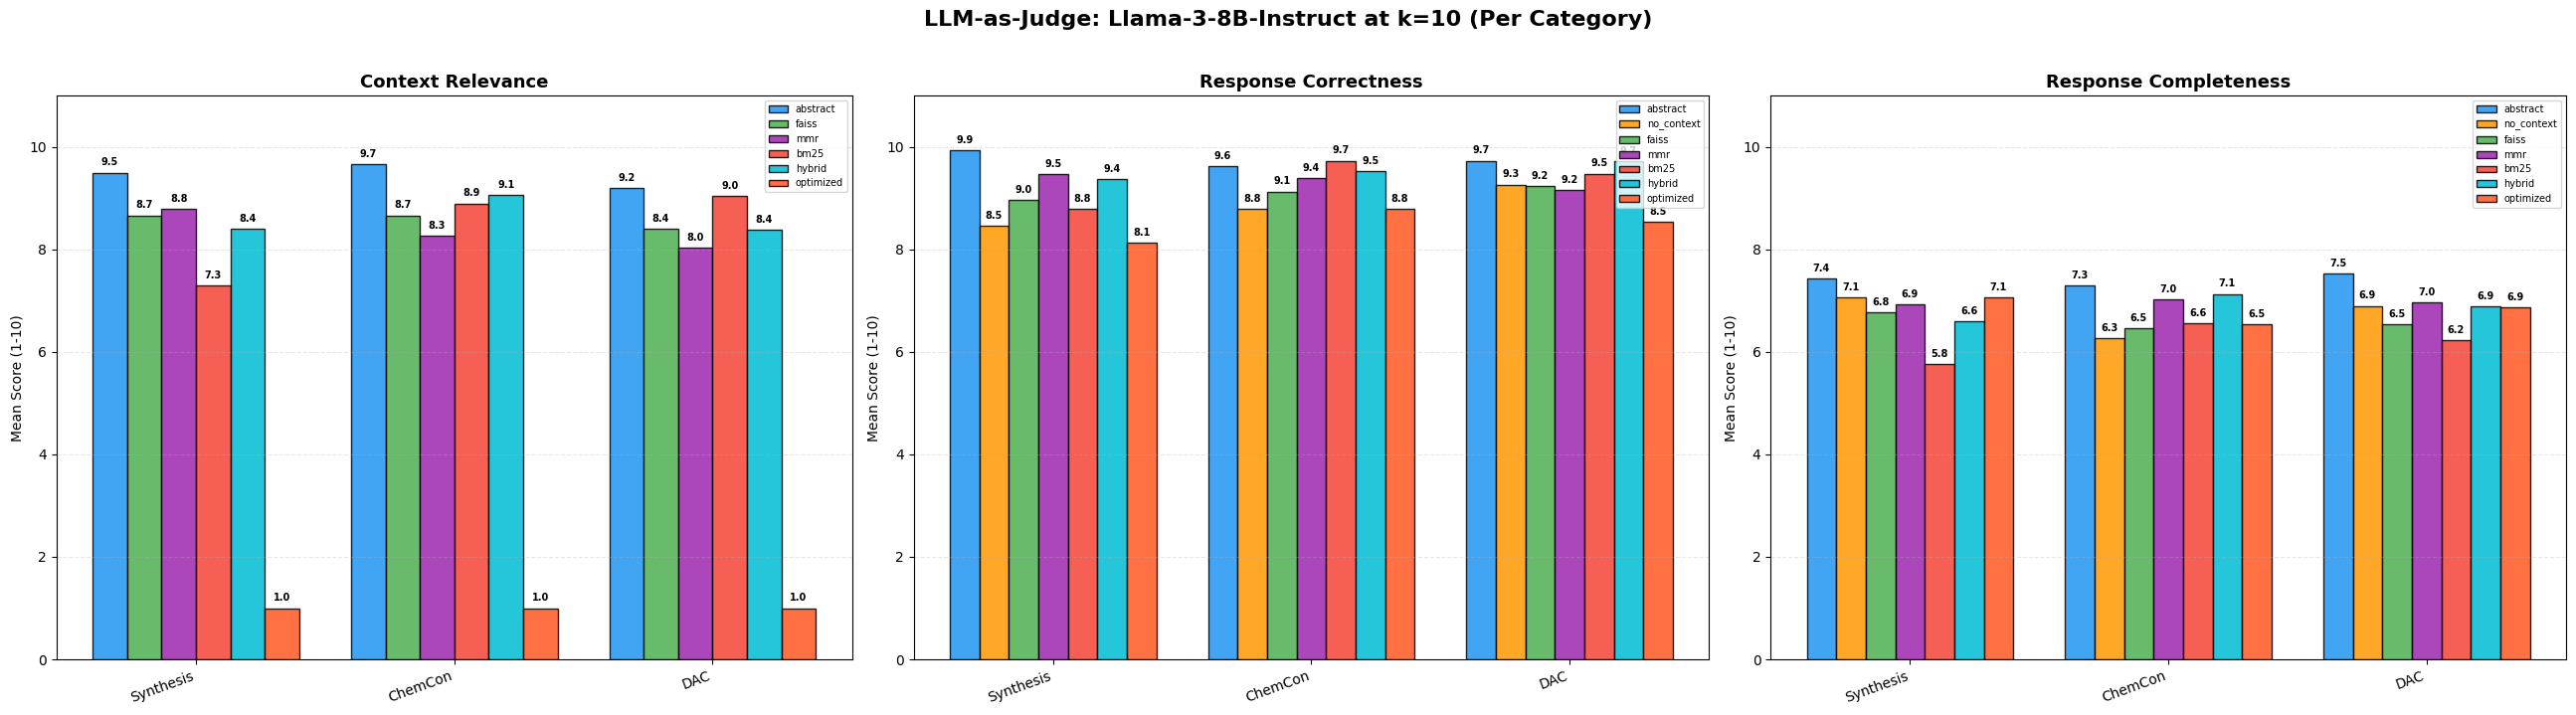

✓ Per-category chart saved


In [34]:
# ============================================================
# Plot 1: Per-category scores at k=10 — one subplot per task
# ============================================================
method_colors = {
    'abstract': '#2196F3', 'no_context': '#FF9800', 'faiss': '#4CAF50',
    'mmr': '#9C27B0', 'bm25': '#F44336', 'hybrid': '#00BCD4', 'optimized': '#FF5722'
}

tasks = [
    ('relevance_mean', 'Context Relevance'),
    ('correctness_mean', 'Response Correctness'),
    ('completeness_mean', 'Response Completeness')
]

k_plot = K_LABELS[0]  # k=10
df_k = summary_df[summary_df['k'] == k_plot]

fig, axes = plt.subplots(1, 3, figsize=(26, 7))

for ax_idx, (col, title) in enumerate(tasks):
    ax = axes[ax_idx]
    
    # For relevance, skip no_context (score is N/A)
    methods_to_plot = ALL_METHODS if col != 'relevance_mean' else [m for m in ALL_METHODS if m != 'no_context']
    
    x = np.arange(len(ALL_CATEGORIES))
    n_methods = len(methods_to_plot)
    bar_width = 0.8 / n_methods
    
    for i, method in enumerate(methods_to_plot):
        scores = []
        for cat in ALL_CATEGORIES:
            row = df_k[(df_k['category'] == cat) & (df_k['method'] == method)]
            if not row.empty and not np.isnan(row[col].values[0]):
                scores.append(row[col].values[0])
            else:
                scores.append(0)
        
        bars = ax.bar(x + i * bar_width, scores, bar_width,
                      label=method, color=method_colors.get(method, '#999'),
                      alpha=0.85, edgecolor='black')
        
        for bar, s in zip(bars, scores):
            if s > 0:
                ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.1,
                        f'{s:.1f}', ha='center', va='bottom', fontweight='bold', fontsize=7)
    
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xticks(x + bar_width * (n_methods - 1) / 2)
    ax.set_xticklabels(ALL_CATEGORIES, rotation=20, ha='right', fontsize=10)
    ax.set_ylabel('Mean Score (1-10)', fontsize=10)
    ax.set_ylim(0, 11)
    ax.legend(loc='upper right', fontsize=7, frameon=True)
    ax.grid(axis='y', alpha=0.3, linestyle='--')

fig.suptitle(f'LLM-as-Judge: {MODEL_NAME} at {k_plot} (Per Category)',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'judge_per_category_{k_plot}_{judge_timestamp}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\u2713 Per-category chart saved")

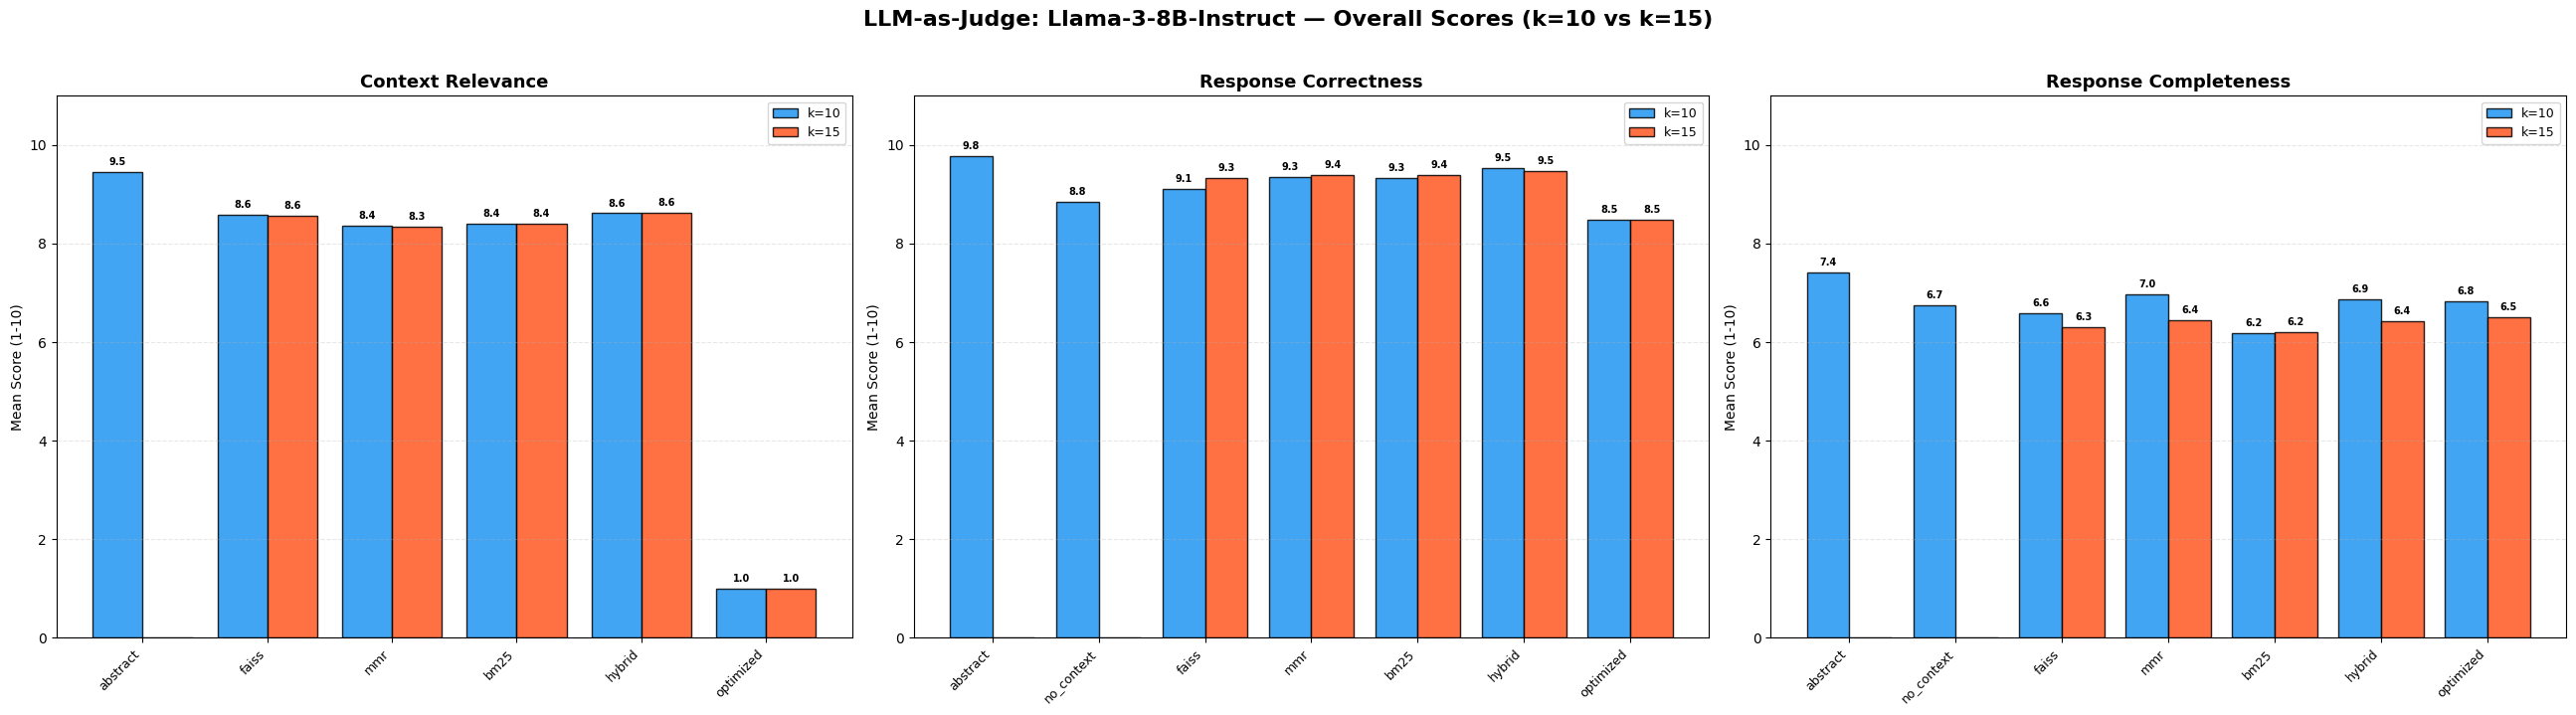

✓ Overall k-comparison chart saved


In [35]:
# ============================================================
# Plot 2: Overall scores (averaged across categories) — all methods side by side
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(26, 7))

for ax_idx, (col, title) in enumerate(tasks):
    ax = axes[ax_idx]
    
    methods_to_plot = ALL_METHODS if col != 'relevance_mean' else [m for m in ALL_METHODS if m != 'no_context']
    
    # Compute overall mean per method across categories (for each k)
    x = np.arange(len(methods_to_plot))
    n_k = len(K_LABELS)
    bar_width = 0.8 / max(n_k, 1)
    
    for k_idx, k_label in enumerate(K_LABELS):
        overall_scores = []
        for method in methods_to_plot:
            # Skip baselines at k>10
            if method in BASELINE_METHODS and k_label != K_LABELS[0]:
                overall_scores.append(0)
                continue
            
            df_sub = summary_df[(summary_df['k'] == k_label) & (summary_df['method'] == method)]
            if not df_sub.empty:
                mean_val = df_sub[col].mean()
                overall_scores.append(mean_val if not np.isnan(mean_val) else 0)
            else:
                overall_scores.append(0)
        
        color = '#2196F3' if k_idx == 0 else '#FF5722'
        bars = ax.bar(x + k_idx * bar_width, overall_scores, bar_width,
                      label=k_label, color=color, alpha=0.85, edgecolor='black')
        
        for bar, s in zip(bars, overall_scores):
            if s > 0:
                ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.1,
                        f'{s:.1f}', ha='center', va='bottom', fontweight='bold', fontsize=7)
    
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xticks(x + bar_width * (n_k - 1) / 2)
    ax.set_xticklabels(methods_to_plot, rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('Mean Score (1-10)', fontsize=10)
    ax.set_ylim(0, 11)
    ax.legend(loc='upper right', fontsize=9, frameon=True)
    ax.grid(axis='y', alpha=0.3, linestyle='--')

fig.suptitle(f'LLM-as-Judge: {MODEL_NAME} — Overall Scores (k=10 vs k=15)',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'judge_overall_k_comparison_{judge_timestamp}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\u2713 Overall k-comparison chart saved")

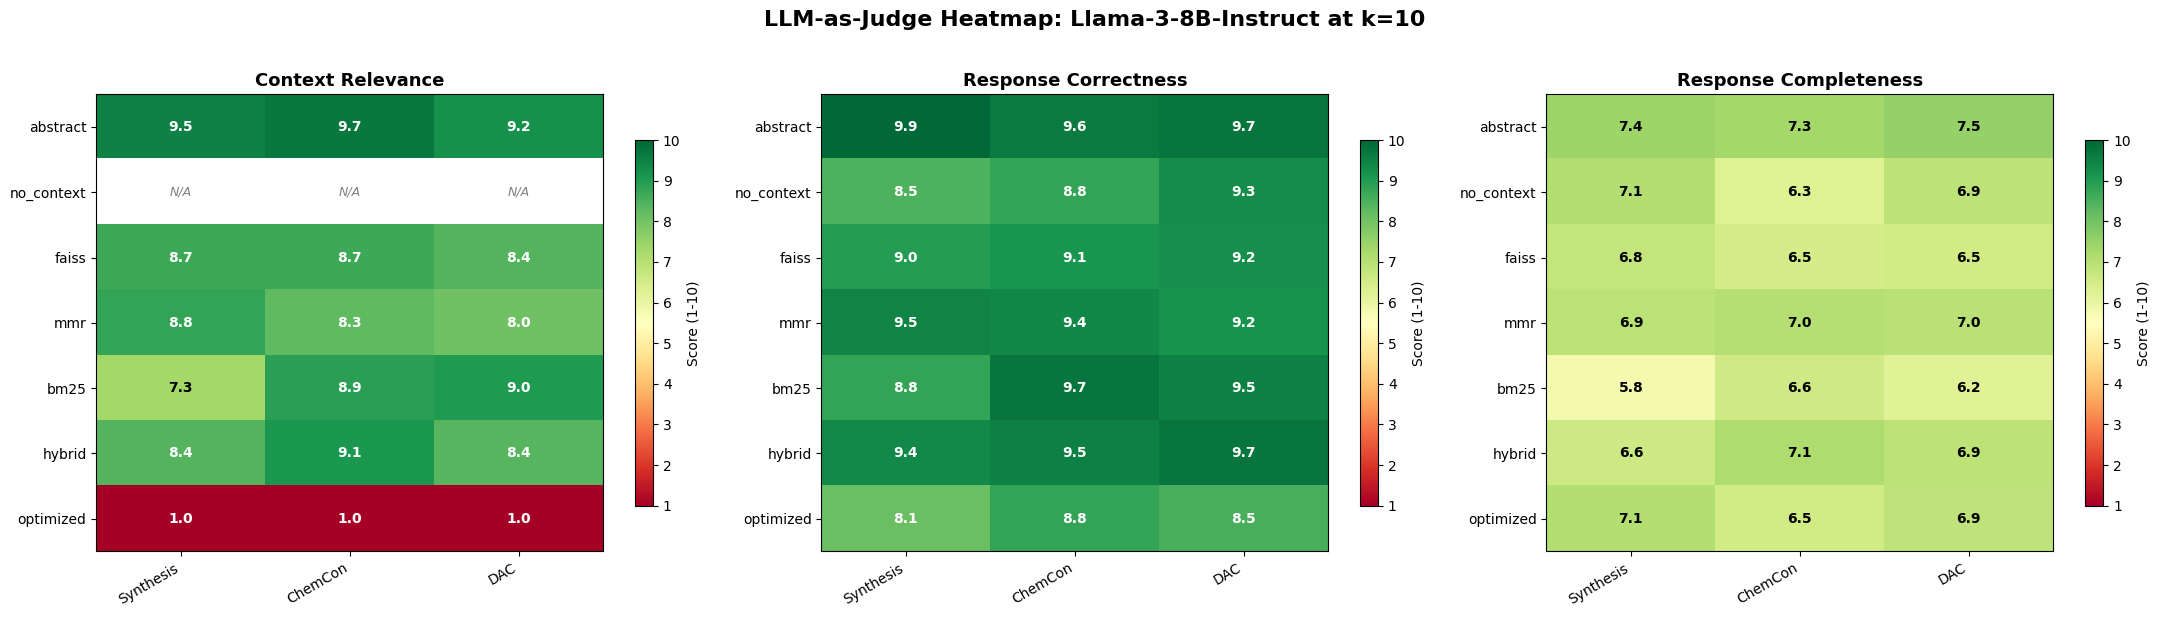

✓ Heatmap chart saved


In [36]:
# ============================================================
# Plot 3: Heatmap — Methods × Categories for each task (k=10)
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

k_plot = K_LABELS[0]  # k=10
df_k = summary_df[summary_df['k'] == k_plot]

for ax_idx, (col, title) in enumerate(tasks):
    ax = axes[ax_idx]
    
    # Build matrix: rows = methods, cols = categories
    matrix = []
    method_labels = []
    for method in ALL_METHODS:
        row_vals = []
        for cat in ALL_CATEGORIES:
            r = df_k[(df_k['method'] == method) & (df_k['category'] == cat)]
            if not r.empty and not np.isnan(r[col].values[0]):
                row_vals.append(r[col].values[0])
            else:
                row_vals.append(np.nan)
        matrix.append(row_vals)
        method_labels.append(method)
    
    matrix = np.array(matrix, dtype=float)
    
    im = ax.imshow(matrix, cmap='RdYlGn', aspect='auto', vmin=1, vmax=10)
    
    # Add text annotations
    for i in range(len(method_labels)):
        for j in range(len(ALL_CATEGORIES)):
            val = matrix[i, j]
            if not np.isnan(val):
                text_color = 'white' if val < 4 or val > 8 else 'black'
                ax.text(j, i, f'{val:.1f}', ha='center', va='center',
                        fontweight='bold', fontsize=10, color=text_color)
            else:
                ax.text(j, i, 'N/A', ha='center', va='center',
                        fontsize=9, color='gray', fontstyle='italic')
    
    ax.set_xticks(range(len(ALL_CATEGORIES)))
    ax.set_xticklabels(ALL_CATEGORIES, rotation=30, ha='right', fontsize=10)
    ax.set_yticks(range(len(method_labels)))
    ax.set_yticklabels(method_labels, fontsize=10)
    ax.set_title(title, fontsize=13, fontweight='bold')
    plt.colorbar(im, ax=ax, shrink=0.8, label='Score (1-10)')

fig.suptitle(f'LLM-as-Judge Heatmap: {MODEL_NAME} at {k_plot}',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'judge_heatmap_{k_plot}_{judge_timestamp}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\u2713 Heatmap chart saved")

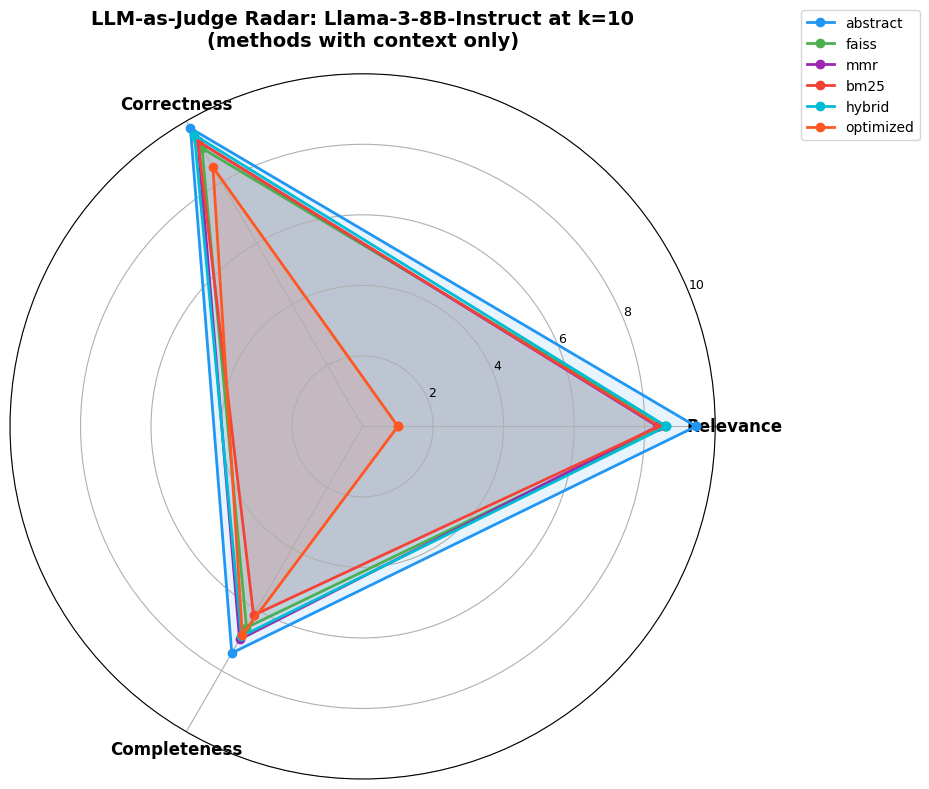

✓ Radar chart saved


In [37]:
# ============================================================
# Plot 4: Radar/Spider chart — Overall profile per method (k=10)
# ============================================================
from matplotlib.patches import FancyBboxPatch

k_plot = K_LABELS[0]  # k=10
df_k = summary_df[summary_df['k'] == k_plot]

task_labels = ['Relevance', 'Correctness', 'Completeness']
task_cols = ['relevance_mean', 'correctness_mean', 'completeness_mean']

# Methods that have all 3 scores (skip no_context which has no relevance)
methods_with_all = [m for m in ALL_METHODS if m != 'no_context']

fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(polar=True))

angles = np.linspace(0, 2 * np.pi, len(task_labels), endpoint=False).tolist()
angles += angles[:1]  # close the polygon

for method in methods_with_all:
    m_data = df_k[df_k['method'] == method]
    if m_data.empty:
        continue
    
    values = []
    for col in task_cols:
        mean_val = m_data[col].mean()
        values.append(mean_val if not np.isnan(mean_val) else 0)
    values += values[:1]  # close the polygon
    
    color = method_colors.get(method, '#999')
    ax.plot(angles, values, 'o-', linewidth=2, label=method, color=color)
    ax.fill(angles, values, alpha=0.1, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(task_labels, fontsize=12, fontweight='bold')
ax.set_ylim(0, 10)
ax.set_yticks([2, 4, 6, 8, 10])
ax.set_yticklabels(['2', '4', '6', '8', '10'], fontsize=9)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10, frameon=True)
ax.set_title(f'LLM-as-Judge Radar: {MODEL_NAME} at {k_plot}\n(methods with context only)',
             fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig(f'judge_radar_{k_plot}_{judge_timestamp}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\u2713 Radar chart saved")

## Score Distribution Analysis

Examine the distribution of individual scores to understand score spread and identify outliers.

/tmp/ipykernel_2400130/86616626.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=labels, patch_artist=True, widths=0.6)
/tmp/ipykernel_2400130/86616626.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=labels, patch_artist=True, widths=0.6)
/tmp/ipykernel_2400130/86616626.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=labels, patch_artist=True, widths=0.6)


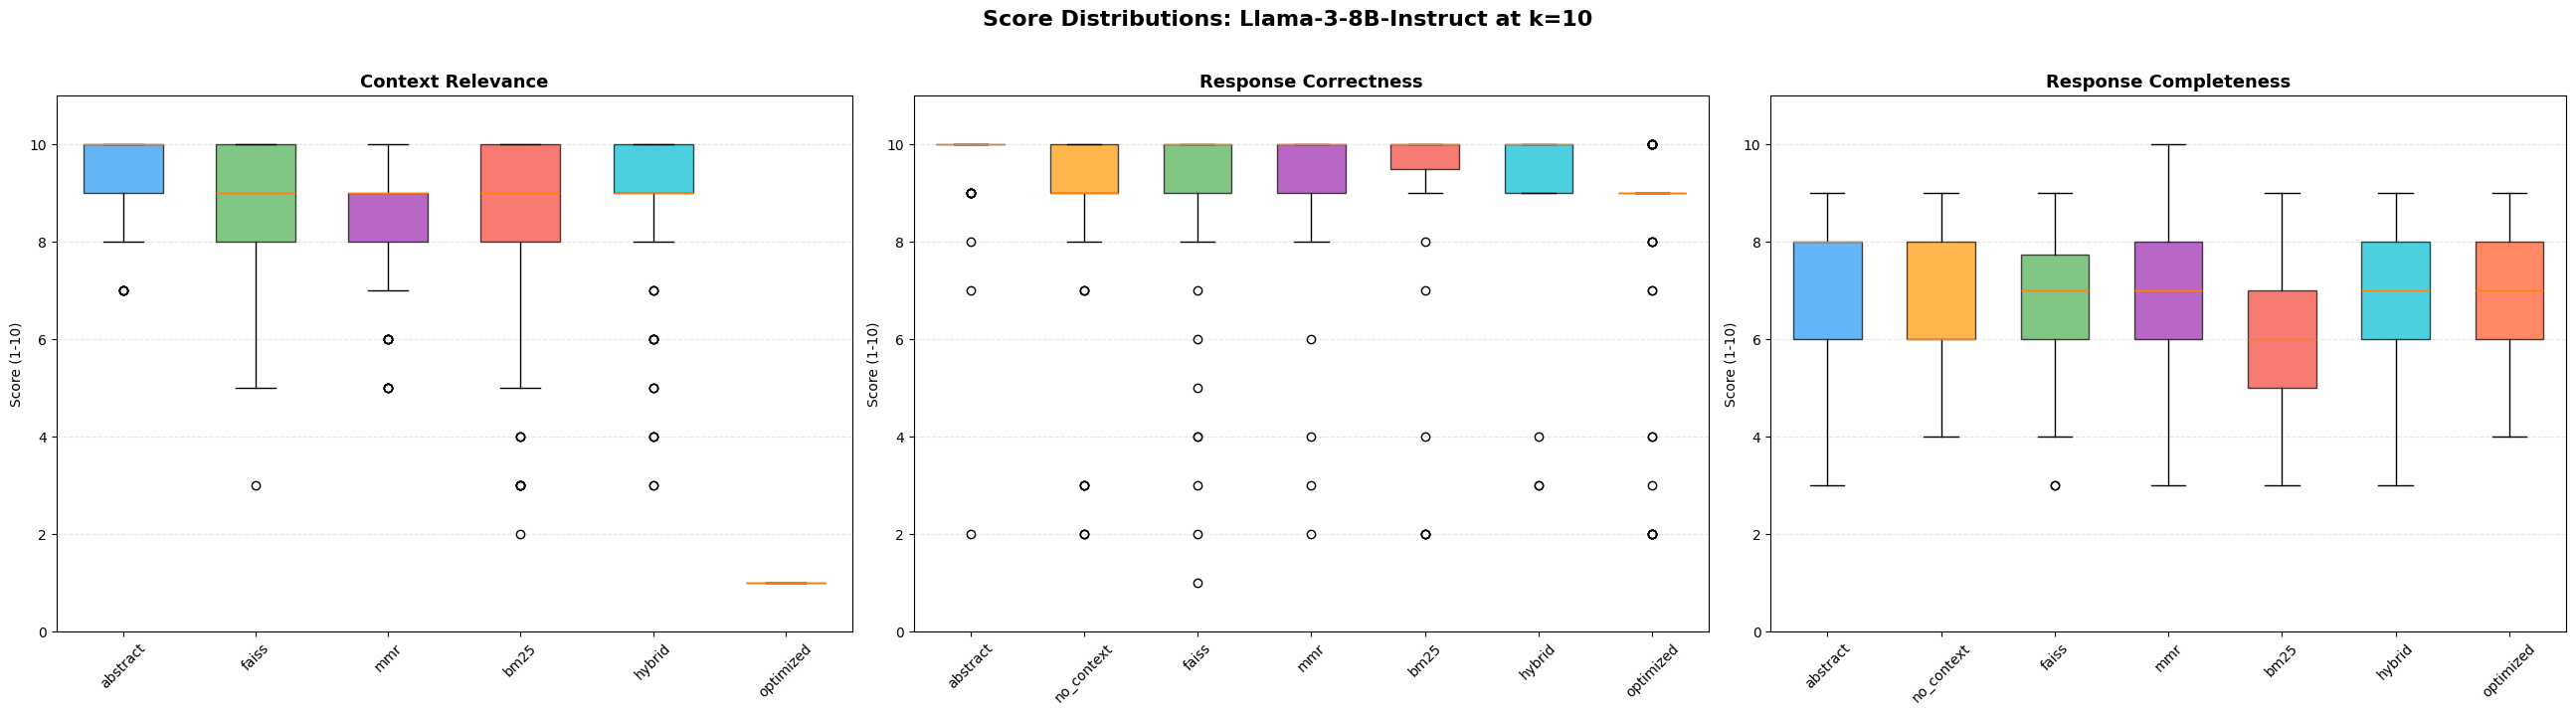

✓ Box plot chart saved


In [38]:
# ============================================================
# Score distributions: box plots per method (k=10)
# ============================================================
k_plot = K_LABELS[0]

fig, axes = plt.subplots(1, 3, figsize=(26, 7))

score_keys = [
    ('relevance_score', 'Context Relevance'),
    ('correctness_score', 'Response Correctness'),
    ('completeness_score', 'Response Completeness')
]

for ax_idx, (score_key, title) in enumerate(score_keys):
    ax = axes[ax_idx]
    
    methods_to_plot = ALL_METHODS if score_key != 'relevance_score' else [m for m in ALL_METHODS if m != 'no_context']
    
    box_data = []
    labels = []
    colors = []
    
    for method in methods_to_plot:
        all_scores = []
        for cat in ALL_CATEGORIES:
            entries = judge_results.get(k_plot, {}).get(cat, {}).get(method, [])
            all_scores.extend([e[score_key] for e in entries if e[score_key] > 0])
        
        if all_scores:
            box_data.append(all_scores)
            labels.append(method)
            colors.append(method_colors.get(method, '#999'))
    
    bp = ax.boxplot(box_data, labels=labels, patch_artist=True, widths=0.6)
    
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Score (1-10)', fontsize=10)
    ax.set_ylim(0, 11)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.tick_params(axis='x', rotation=45)

fig.suptitle(f'Score Distributions: {MODEL_NAME} at {k_plot}',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'judge_boxplots_{k_plot}_{judge_timestamp}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\u2713 Box plot chart saved")

## Correlation: MCQ Accuracy vs Judge Scores

Compare the MCQ accuracy from 23e with the LLM-as-Judge scores to see if they align.

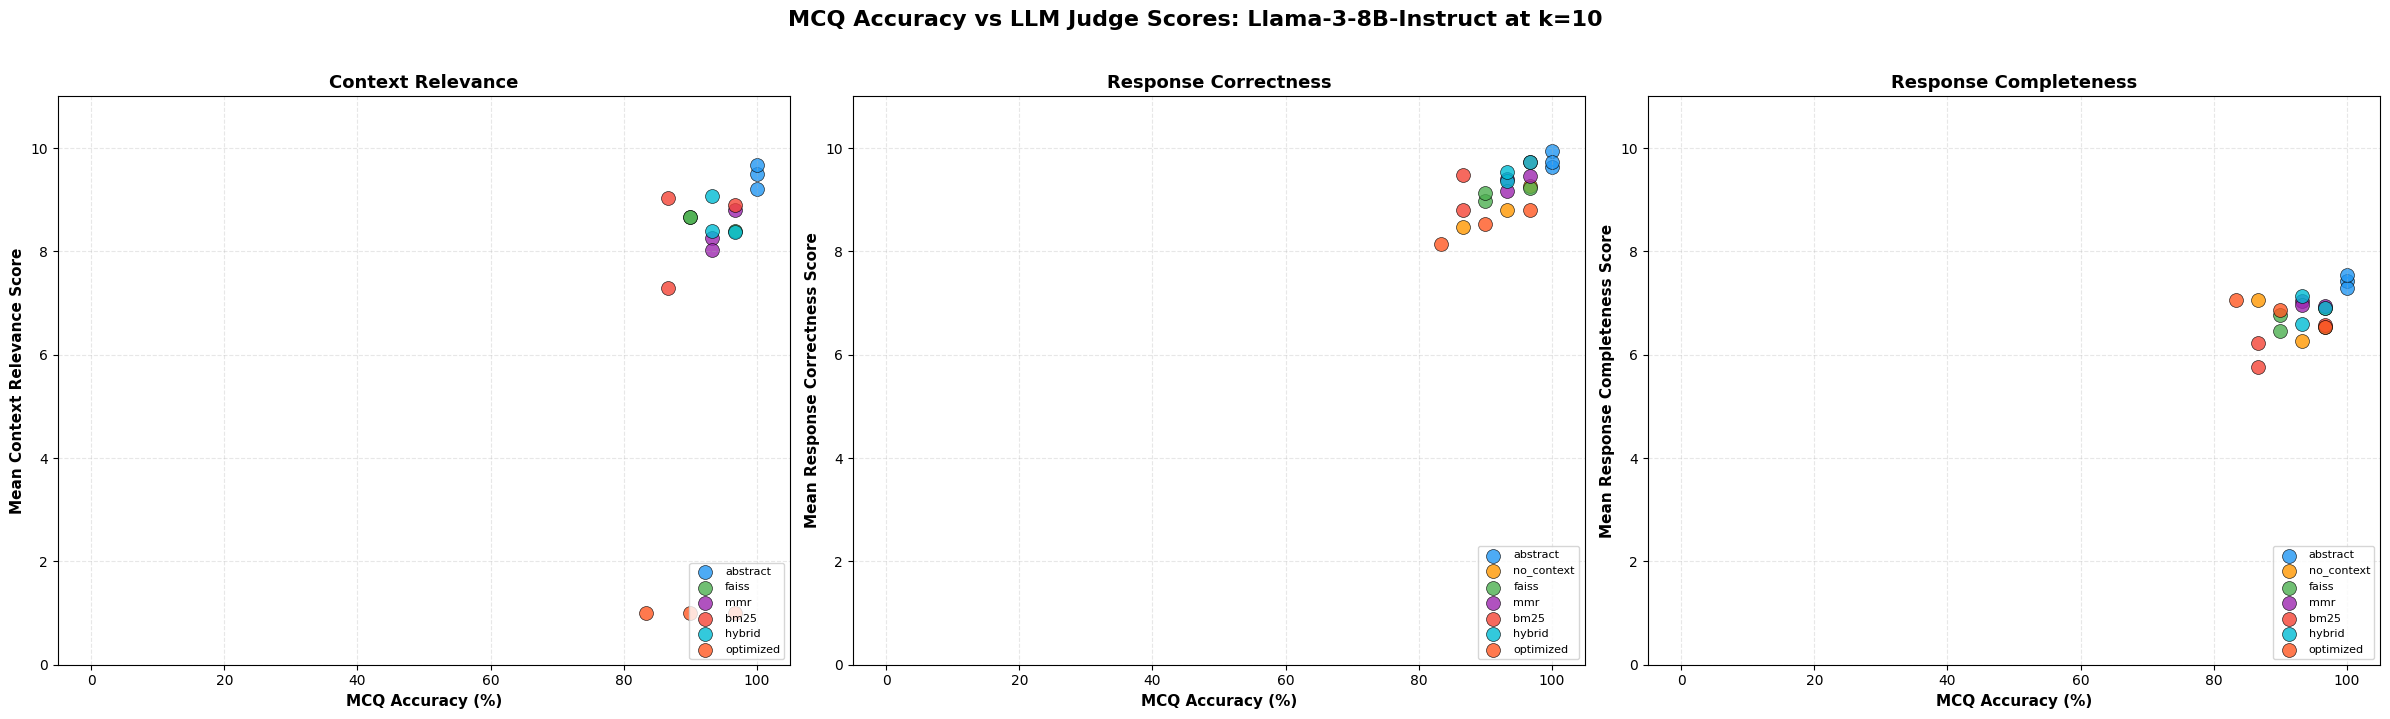

✓ Accuracy vs Judge score scatter plots saved


In [39]:
# ============================================================
# Scatter plot: MCQ Accuracy vs mean Judge scores
# ============================================================
k_plot = K_LABELS[0]

fig, axes = plt.subplots(1, 3, figsize=(24, 7))

for ax_idx, (col, title) in enumerate(tasks):
    ax = axes[ax_idx]
    
    for method in ALL_METHODS:
        if col == 'relevance_mean' and method == 'no_context':
            continue
        
        for cat in ALL_CATEGORIES:
            # MCQ accuracy from source results
            src = all_results.get(MODEL_NAME, {}).get(k_plot, {}).get(cat, {}).get(method, {})
            mcq_acc = src.get('accuracy', 0)
            
            # Judge score
            judge_row = summary_df[
                (summary_df['k'] == k_plot) & 
                (summary_df['category'] == cat) & 
                (summary_df['method'] == method)
            ]
            
            if not judge_row.empty and not np.isnan(judge_row[col].values[0]):
                judge_score = judge_row[col].values[0]
                
                ax.scatter(mcq_acc, judge_score,
                          color=method_colors.get(method, '#999'),
                          s=100, alpha=0.8, edgecolors='black', linewidth=0.5,
                          label=method if cat == ALL_CATEGORIES[0] else None)
    
    ax.set_xlabel('MCQ Accuracy (%)', fontsize=11, fontweight='bold')
    ax.set_ylabel(f'Mean {title} Score', fontsize=11, fontweight='bold')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlim(-5, 105)
    ax.set_ylim(0, 11)
    ax.grid(alpha=0.3, linestyle='--')
    
    # Remove duplicate legend entries
    handles, lbls = ax.get_legend_handles_labels()
    by_label = dict(zip(lbls, handles))
    ax.legend(by_label.values(), by_label.keys(), loc='lower right', fontsize=8, frameon=True)

fig.suptitle(f'MCQ Accuracy vs LLM Judge Scores: {MODEL_NAME} at {k_plot}',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'judge_vs_accuracy_{k_plot}_{judge_timestamp}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\u2713 Accuracy vs Judge score scatter plots saved")

In [40]:
# ============================================================
# Final Summary
# ============================================================
print("\n" + "="*80)
print("LLM-AS-JUDGE EVALUATION COMPLETE")
print("="*80)
print(f"\nModel evaluated: {MODEL_NAME}")
print(f"Judge model: GPT-4.1")
print(f"Questions judged: {total_evaluated}")
print(f"Categories: {ALL_CATEGORIES}")
print(f"Methods: {ALL_METHODS}")
print(f"K values: {K_LABELS}")
print(f"\nSaved files:")
print(f"  Results JSON: {final_save_path}")
print(f"  Summary CSV:  {summary_csv}")
print(f"\nVisualization PNGs:")
for png in sorted(glob.glob(f'judge_*_{judge_timestamp}.png')):
    print(f"  {png}")
print("="*80)


LLM-AS-JUDGE EVALUATION COMPLETE

Model evaluated: Llama-3-8B-Instruct
Judge model: GPT-4.1
Questions judged: 1080
Categories: ['Synthesis', 'ChemCon', 'DAC']
Methods: ['abstract', 'no_context', 'faiss', 'mmr', 'bm25', 'hybrid', 'optimized']
K values: ['k=10', 'k=15']

Saved files:
  Results JSON: judge_results_final_20260303_215545.json
  Summary CSV:  judge_summary_20260303_215545.csv

Visualization PNGs:
  judge_boxplots_k=10_20260303_215545.png
  judge_heatmap_k=10_20260303_215545.png
  judge_overall_k_comparison_20260303_215545.png
  judge_per_category_k=10_20260303_215545.png
  judge_radar_k=10_20260303_215545.png
  judge_vs_accuracy_k=10_20260303_215545.png
